In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
%matplotlib inline
import warnings

In [2]:
df= pd.read_csv(r'D:\project\notebook\data\student.csv')
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
x= df.drop(columns=['math_score'], axis=1)
y=df['math_score']

In [4]:
x.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [5]:
print("categories in 'gender' variable: ",end=" ")
print(df['gender'].unique())

print("categories in 'race_ethnicity' variable :", end=" ")
print(df['race_ethnicity'].unique())

print("categories in 'parental_level_of_education' variable :", end=" ")
print(df['parental_level_of_education'].unique())

print("categories in 'lunch' variable :", end=" ")
print(df['lunch'].unique())

print("categories in 'test_preparation_course' variable :", end=" ")
print(df['test_preparation_course'].unique())


categories in 'gender' variable:  ['female' 'male']
categories in 'race_ethnicity' variable : ['group B' 'group C' 'group A' 'group D' 'group E']
categories in 'parental_level_of_education' variable : ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
categories in 'lunch' variable : ['standard' 'free/reduced']
categories in 'test_preparation_course' variable : ['none' 'completed']


In [6]:
## create column transformers
num_features= x.select_dtypes(exclude="object").columns
cat_features= x.select_dtypes(include='object').columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer= OneHotEncoder()

preprocessor=ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
        ("standardscaler", numeric_transformer, num_features),
    ]
)

In [7]:
x=preprocessor.fit_transform(x)

In [8]:
x

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]], shape=(1000, 19))

In [9]:
## train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.3, random_state=42)
 

In [10]:
x_train.shape, x_test.shape

((700, 19), (300, 19))

### create evaluation Function 

In [14]:
def evaluation_model(true, predicted):
    mae= mean_absolute_error(true,predicted)
    mse= mean_squared_error(true,predicted)
    rmse=np.sqrt(mse)
    r2=r2_score(true,predicted)
    return mae, mse, rmse,r2

In [15]:
model = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "k Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoostRegressor": CatBoostRegressor(verbose=False),
    "AdaBoostRegressor": AdaBoostRegressor()
}
model_list = []
r2_list = []

for name, model in model.items():
    model.fit(x_train, y_train)
    
    # make predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)
    
    # Evaluate the model
    model_train_mae, model_train_mse, model_train_rmse, model_train_r2 = evaluation_model(y_train, y_train_pred)
    model_test_mae, model_test_mse, model_test_rmse, model_test_r2 = evaluation_model(y_test, y_test_pred)
    
    print(name)
    model_list.append(name)
    
    print("Model performance for Training set")
    print("-Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("-Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("-R2 score: {:.4f}".format(model_train_r2))
    
    print("----------------------------------------------")
    
    print("Model performance for Test set")
    print("-Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("-Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("-R2 score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)

    print('='*35)
    print('\n')
    

Linear Regression
Model performance for Training set
-Root Mean Squared Error: 5.2483
-Mean Absolute Error: 4.1985
-R2 score: 0.8751
----------------------------------------------
Model performance for Test set
-Root Mean Squared Error: 5.5576
-Mean Absolute Error: 4.4183
-R2 score: 0.8759


Lasso
Model performance for Training set
-Root Mean Squared Error: 6.5106
-Mean Absolute Error: 5.1582
-R2 score: 0.8078
----------------------------------------------
Model performance for Test set
-Root Mean Squared Error: 6.8705
-Mean Absolute Error: 5.3929
-R2 score: 0.8103


Ridge
Model performance for Training set
-Root Mean Squared Error: 5.2487
-Mean Absolute Error: 4.1977
-R2 score: 0.8751
----------------------------------------------
Model performance for Test set
-Root Mean Squared Error: 5.5566
-Mean Absolute Error: 4.4155
-R2 score: 0.8759


k Neighbors Regressor
Model performance for Training set
-Root Mean Squared Error: 5.6784
-Mean Absolute Error: 4.5037
-R2 score: 0.8538
--------

## Resulta

In [16]:
pd.DataFrame(list(zip(model_list,r2_list)), columns=['Model Name', 'R2_score']).sort_values(by=["R2_score"],ascending=False)

,Model Name,R2_score
2,Ridge,0.875907
0,Linear Regression,0.875863
7,CatBoostRegressor,0.852108
5,Random Forest,0.849168
8,AdaBoostRegressor,0.837489
6,XGBRegressor,0.811816
1,Lasso,0.810281
3,k Neighbors Regressor,0.772328
4,Decision Tree,0.728535


## Linear Regression

In [17]:
lin_model= LinearRegression(fit_intercept=True)
lin_model=lin_model.fit(x_train, y_train)
y_pred= lin_model.predict(x_test)
score=r2_score(y_test,y_pred)*100
print("Accuracy of the model is %.2f"%score)

Accuracy of the model is 87.59


## plot y_pred and y_test

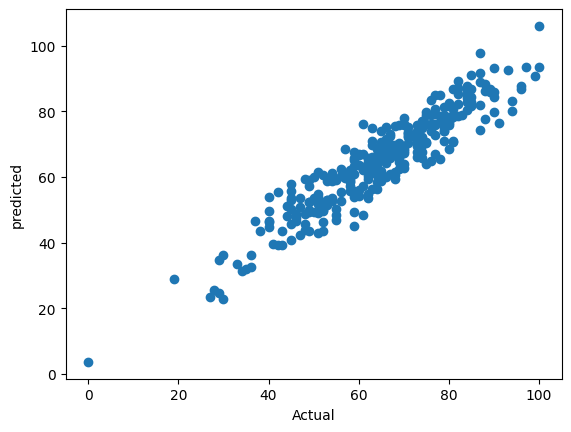

In [22]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual');
plt.ylabel('predicted');

<Axes: xlabel='math_score'>

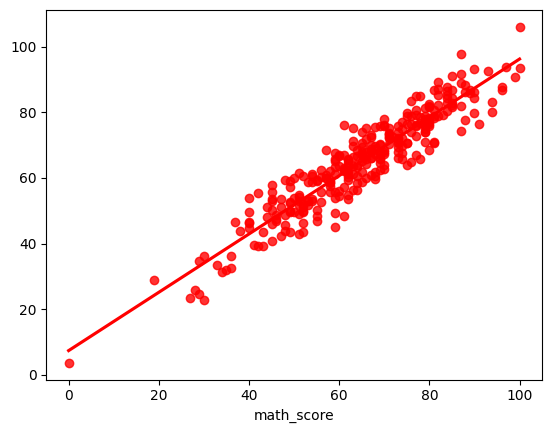

In [23]:
sns.regplot(x=y_test, y=y_pred, ci=None,color='red')

### Difference between actual and predicted value

In [25]:
pred_df=pd.DataFrame({'Actual value' :y_test,'predicted value':y_pred,'Dfference':y_test-y_pred})
pred_df

,Actual value,predicted value,Dfference
521,91,76.511652,14.488348
737,53,58.898180,-5.898180
740,80,76.938478,3.061522
660,74,76.965881,-2.965881
411,84,87.633152,-3.633152
...,...,...,...
468,77,72.854766,4.145234
935,70,62.606548,7.393452
428,65,58.650347,6.349653
7,40,44.841375,-4.841375
